# Predicting Wine Price from Review Text with Partially Frozen ModernBERT

## 基本情報

- 主題: ModernBERTの最終層だけをfine-tuningする
- 作成者: 荒田禎之
- 位置づけ: 事前学習済みencoderの大部分を凍結する転移学習
- 使用データ: Wine Review
- 分析課題: レビュー本文からワイン価格を予測する回帰
- 到達目標: `requires_grad` を使った層の凍結と部分的fine-tuningを理解する

This notebook includes code and explanations generated with OpenAI Codex.

---

## 1. 今回の方針

`description` のみから $\log(\mathrm{price})$ を予測する回帰モデルを作る。英語・コードで事前学習された [`answerdotai/ModernBERT-base`](https://huggingface.co/answerdotai/ModernBERT-base) を使用する。

全22層を更新するのではなく、encoderの大部分を凍結し、最後の4層、encoderの最終LayerNorm、タスク固有の回帰headだけを学習する。これにより、full fine-tuningより学習可能パラメータ数、optimizer state、backward計算を削減する。

層の凍結は、Hugging Face公式ガイドの [`model.base_model.parameters()` に対して `requires_grad=False` を設定する方法](https://huggingface.co/transformers/v4.2.2/training.html#freezing-the-encoder) に沿う。参照ページはTransformers v4.2.2のlegacy documentationでModernBERT登場前の資料だが、PyTorchの `requires_grad` を使う原則は現在のModernBERTにも適用できる。


In [1]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U "transformers>=4.48.0" datasets accelerate scikit-learn

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

sns.set_theme(style="whitegrid")
SEED = 42

## 1. データの読み込みと重複除外

<!-- 同じレビュー本文が訓練データと評価データに分かれないよう、`description` が重複する行を除外します。価格が欠損または非正の行も除外します。 -->

CSVを `data/` または `../data/` から探索して読み込む。本文が欠損した行、価格が欠損または非正の行を除き、同じ `description` を持つ重複レビューを削除する。本文列を `text`、価格の自然対数を `float32` の `label` とし、対象行数、先頭データ、目的変数の分布を表示する。


In [ ]:
filename = "winemag-data-130k-v2.csv"
candidate_paths = [Path("data") / filename, Path("../data") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

if csv_path is None:
    searched = "\n".join(f"- {path.resolve()}" for path in candidate_paths)
    raise FileNotFoundError(f"CSV が見つかりません。以下を確認してください。\n{searched}")

df = pd.read_csv(csv_path)
rows_before = len(df)

model_data = (
    df.loc[
        df["description"].notna()
        & df["price"].notna()
        & (df["price"] > 0),
        ["description", "price"],
    ]
    .drop_duplicates(subset=["description"])
    .rename(columns={"description": "text"})
    .reset_index(drop=True)
)
model_data["label"] = np.log(model_data["price"]).astype("float32")

print(f"Loaded: {csv_path.resolve()}")
print(f"Original rows: {rows_before:,}")
print(f"Rows used after filtering and deduplication: {len(model_data):,}")
display(model_data.head())
display(model_data["label"].describe().rename("log_price").to_frame())

### `description` の文字数分布

<!-- 重複除外と価格フィルタリング後のレビュー本文について、文字数の要約統計と分布を確認します。 -->

レビュー本文の文字数を行ごとに計算し、平均、標準偏差、四分位点、90・95・99パーセンタイル、最大値を表示する。ヒストグラムには中央値を破線で示す。この文字数分布は、後続の最大トークン長を検討する参考になるが、文字数とトークン数は同一ではない（トークンは単語等で区切られたものなので、トークン数の数倍が文字数のイメージ）。


,description_length
count,111567.000000
mean,244.477328
std,67.187402
min,20.000000
50%,239.000000
75%,285.000000
90%,331.000000
95%,362.000000
99%,431.000000
max,829.000000


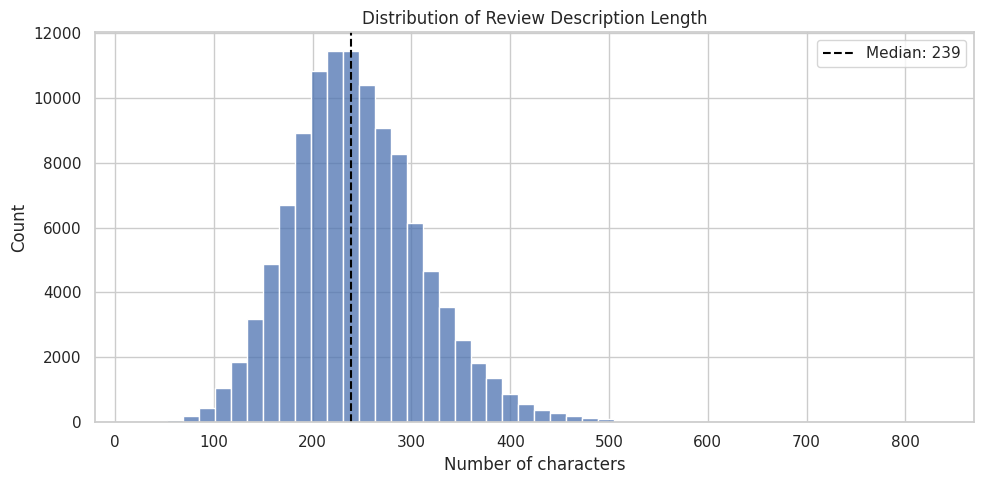

In [3]:
description_length = model_data["text"].str.len()
length_summary = description_length.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).rename("description_length")
display(length_summary.to_frame())

plt.figure(figsize=(10, 5))
sns.histplot(description_length, bins=50, color="#4C72B0")
plt.axvline(
    description_length.median(),
    color="black",
    linestyle="--",
    label=f"Median: {description_length.median():.0f}",
)
plt.title("Distribution of Review Description Length")
plt.xlabel("Number of characters")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


## 2. ModernBERTの準備、層の凍結、データ分割

80%を訓練、10%を検証、10%を最終テストに使う。動作確認だけを短時間で行いたい場合は `MAX_ROWS` に行数を指定する。

`answerdotai/ModernBERT-base` のtokenizerと回帰モデルを読み込む。`num_labels=1` と `problem_type="regression"` により、出力を1つの連続値にする。

Hugging Face公式ガイドと同様に、最初に `model.base_model.parameters()` の `requires_grad` をすべて `False` にしてencoder全体を凍結する。その後、ModernBERTの `model.base_model.layers` から最後の `NUM_UNFROZEN_LAYERS` 層だけを再度学習可能にする。

最終層の出力に適用される `model.base_model.final_norm` と、タスク用に初期化された `model.head`、`model.classifier` も学習対象にする。特に回帰headは事前学習済み重みに含まれないため、凍結してはいけない。


In [4]:
MODEL_NAME = "answerdotai/ModernBERT-base"
MAX_LENGTH = 256
MAX_ROWS = None  # 例: 10_000。全データを使う場合は None
NUM_UNFROZEN_LAYERS = 4  # encoderの最後から何層を学習するか

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    model_data = model_data.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
)

# 公式ガイドの方法に沿って、まず事前学習済みencoder全体を凍結する。
for parameter in model.base_model.parameters():
    parameter.requires_grad = False

encoder_layers = model.base_model.layers
num_encoder_layers = len(encoder_layers)
if not 1 <= NUM_UNFROZEN_LAYERS <= num_encoder_layers:
    raise ValueError(
        f"NUM_UNFROZEN_LAYERS must be between 1 and {num_encoder_layers}, "
        f"but got {NUM_UNFROZEN_LAYERS}."
    )

# encoderの最後の数層だけを学習可能に戻す。
for layer in encoder_layers[-NUM_UNFROZEN_LAYERS:]:
    for parameter in layer.parameters():
        parameter.requires_grad = True

# 最終encoder層の後に適用されるLayerNormを学習する。
for parameter in model.base_model.final_norm.parameters():
    parameter.requires_grad = True

# 回帰用のprediction headと最終出力層はタスク固有なので必ず学習する。
for module in (model.head, model.classifier):
    for parameter in module.parameters():
        parameter.requires_grad = True

trainable_parameters = sum(
    parameter.numel() for parameter in model.parameters() if parameter.requires_grad
)
total_parameters = sum(parameter.numel() for parameter in model.parameters())
first_unfrozen_layer = num_encoder_layers - NUM_UNFROZEN_LAYERS

print(f"Encoder layers: {num_encoder_layers}")
print(
    "Unfrozen encoder layers: "
    f"{list(range(first_unfrozen_layer, num_encoder_layers))}"
)
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable ratio: {trainable_parameters / total_parameters:.2%}")

# 設定どおりに凍結できていることを検証する。
assert not any(
    parameter.requires_grad for parameter in model.base_model.embeddings.parameters()
)
assert all(
    parameter.requires_grad
    for layer in encoder_layers[-NUM_UNFROZEN_LAYERS:]
    for parameter in layer.parameters()
)
assert all(parameter.requires_grad for parameter in model.head.parameters())
assert all(parameter.requires_grad for parameter in model.classifier.parameters())

dataset = Dataset.from_pandas(
    model_data[["text", "label"]], preserve_index=False
)
train_holdout = dataset.train_test_split(test_size=0.2, seed=SEED)
valid_test = train_holdout["test"].train_test_split(test_size=0.5, seed=SEED)
dataset = DatasetDict({
    "train": train_holdout["train"],
    "validation": valid_test["train"],
    "test": valid_test["test"],
})

print(dataset)


config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoder layers: 22
Unfrozen encoder layers: [18, 19, 20, 21]
Trainable parameters: 20,652,289
Total parameters: 149,605,633
Trainable ratio: 13.80%
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 11157
    })
})


## 3. Tokenization

各レビュー本文をModernBERTのtokenizerでトークン化する。`MAX_LENGTH=256` は文字数ではなく特殊トークンを含む最大トークン数であり、超過部分は末尾から切り詰める。全データをbatch処理し、元の文字列列を削除して `input_ids`、`attention_mask`、`label` を持つ学習用Datasetを作る。paddingはTrainerがbatch作成時に行う。


In [5]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"],
)
tokenized_dataset

Map:   0%|          | 0/89253 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

Map:   0%|          | 0/11157 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 89253
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 11157
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 11157
    })
})

## 4. 評価指標

<!-- 学習時の損失とRMSE・MAE・$R^2$ は log価格で計算します。参考として、ドル価格に戻したMAEも計算します。 -->

Hugging Face `Trainer` が検証・評価時に呼び出す指標計算関数を定義する。モデル出力と正解ラベルを1次元へ整形し、log価格のRMSE、MAE、$R^2$ を計算する。さらに両者を指数変換してドル価格へ戻し、価格単位のMAEも返す。


In [6]:
def compute_metrics(eval_prediction):
    predictions = np.asarray(eval_prediction.predictions).reshape(-1)
    labels = np.asarray(eval_prediction.label_ids).reshape(-1)
    return {
        "rmse": mean_squared_error(labels, predictions) ** 0.5,
        "mae": mean_absolute_error(labels, predictions),
        "r2": r2_score(labels, predictions),
        "price_mae_usd": mean_absolute_error(
            np.exp(labels), np.exp(predictions)
        ),
    }

## 5. 最終層だけのfine-tuning

Hugging Face `Trainer` は、`requires_grad=True` のパラメータについて勾配を計算し、optimizerで更新する。したがって、前節で凍結したembeddingとencoder前半層は更新されず、最後の4層、最終LayerNorm、回帰headだけが学習される。

full fine-tuning版と比較しやすいように、学習率、batch size、最大10 epoch、weight decay、warmup、評価・保存頻度は元ノートブックの設定を維持する。勾配を2 step蓄積するため、1 device当たりの実効訓練batch sizeは $16 \times 2=32$ となる。

GPUがあればfp16を使い、各epochの検証RMSEで最良モデルを選ぶ。RMSEが2回連続で改善しなければearly stoppingし、最後に最良時点の重みを復元する。


In [7]:
training_args = TrainingArguments(
    output_dir="./wine-review-modernbert-freeze",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="rmse",
    greater_is_better=False,
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Rmse,Mae,R2,Price Mae Usd
1,0.544531,0.262830,0.512670,0.397941,0.412540,15.567755
2,0.449637,0.237884,0.487733,0.375288,0.468299,14.903345
3,0.432465,0.254710,0.504688,0.398728,0.430691,15.850097
4,0.387797,0.222679,0.471889,0.361427,0.502282,14.462986
5,0.318811,0.222169,0.471348,0.362777,0.503423,14.545135
6,0.304289,0.229765,0.479339,0.368170,0.486444,14.904869
7,0.245976,0.234454,0.484205,0.373803,0.475964,15.060921


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=19530, training_loss=0.564390761804654, metrics={'train_runtime': 2899.7462, 'train_samples_per_second': 307.796, 'train_steps_per_second': 9.622, 'total_flos': 3.833459591525787e+16, 'train_loss': 0.564390761804654, 'epoch': 7.0})

## 6. テストデータでの最終評価

学習やearly stoppingに使っていないテストDatasetを、最良モデルで評価する。`metric_key_prefix="test"` により、loss、RMSE、MAE、$R^2$、ドル価格MAEなどへ `test_` 接頭辞を付け、表形式で表示する。これが未知データに対する最終性能指標となる。


In [8]:
test_metrics = trainer.evaluate(
    eval_dataset=tokenized_dataset["test"],
    metric_key_prefix="test",
)
display(pd.Series(test_metrics, name="value").to_frame())

[transformers] early stopping required metric_for_best_model, but did not find eval_rmse so early stopping is disabled


Training Loss,Validation Loss,Epoch,Rmse,Mae,R2,Price Mae Usd
0.245976,0.216594,7,0.465396,0.358700,0.499692,13.824743


,value
test_loss,0.216594
test_rmse,0.465396
test_mae,0.358700
test_r2,0.499692
test_price_mae_usd,13.824743


### 予測値と残差を可視化するコード

テストデータ全件の予測を取得し、実際のlog価格、予測log価格、残差を作る。左図は実測値と予測値を45度線と比較し、右図は「実際値 − 予測値」の分布を表示する。45度線からの距離、残差の中心のずれ、長い裾から、誤差の大きさや系統的な過大・過小予測を確認する。


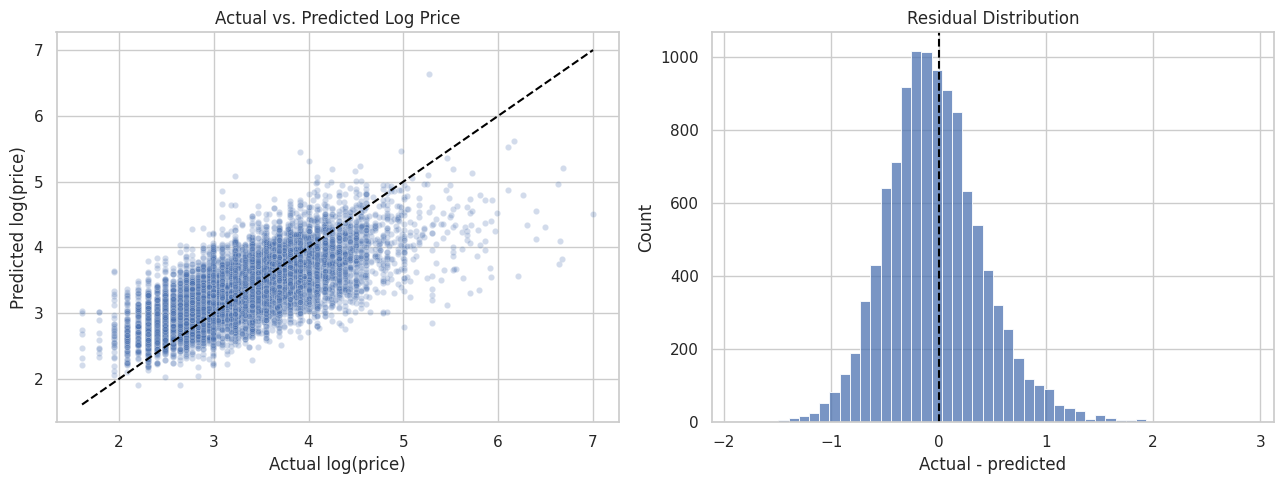

In [9]:
test_output = trainer.predict(tokenized_dataset["test"])
actual_log_price = np.asarray(test_output.label_ids).reshape(-1)
predicted_log_price = np.asarray(test_output.predictions).reshape(-1)
residuals = actual_log_price - predicted_log_price

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    x=actual_log_price,
    y=predicted_log_price,
    alpha=0.25,
    s=20,
    ax=axes[0],
)
limits = [
    min(actual_log_price.min(), predicted_log_price.min()),
    max(actual_log_price.max(), predicted_log_price.max()),
]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()

## 7. 新しいレビュー本文から価格を予測

任意のレビュー本文1件をtokenizeし、学習済みモデルと同じdeviceへ転送して推論する関数を定義する。評価モードと `torch.no_grad()` によりdropoutと勾配計算を無効化し、予測したlog価格と、それを指数変換したドル価格を返す。最後に例文を入力して関数の使用例を表示する。


In [10]:
def predict_price(description):
    inputs = tokenizer(
        description,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)
    model.eval()
    with torch.no_grad():
        predicted_log_price = model(**inputs).logits.squeeze().item()
    return {
        "log_price": predicted_log_price,
        "price_usd": float(np.exp(predicted_log_price)),
    }


example = (
    "A rich and structured red wine with ripe blackberry, dark chocolate, "
    "cedar and a long, balanced finish."
)
print(predict_price(example))

{'log_price': 3.779296875, 'price_usd': 43.78524440968234}
